COMPUTER PROGRAMMING PROJECT - GRETA DELL'AMICO

TASK 1 - CLASS FOR THE PROBLEM

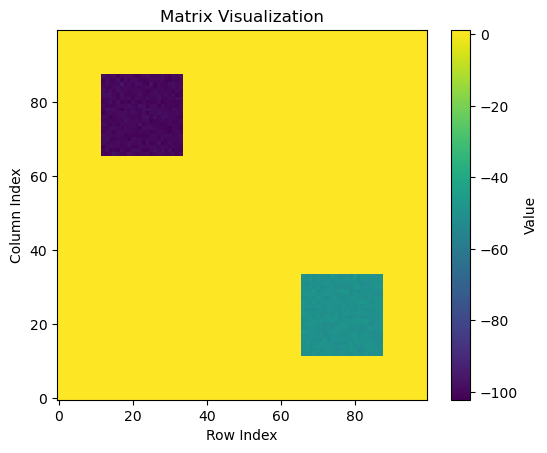

In [212]:
import numpy as np
import matplotlib.pyplot as plt 
from copy import deepcopy

#This is the function that we were given, with my seed
def generate_data(n, seed = "3197417"):
    if type(seed) != str:
        raise TypeError("The seed should be the string representing your ID")
    if type(n) != int:
        raise TypeError("The dimension of the problem should be an integer value")
    if n%2 != 0:
        raise ValueError("The dimension of the problem should be even!!")
    
    aggregate_counter = 0
    for char in seed:
        aggregate_counter += int(char)
    
    aggregate_counter = 10*aggregate_counter
    marginal_diff = int(aggregate_counter)%n 
    bsize = 12 + int(np.floor(n**(1/2)))
    if (bsize%2)!=0:
        bsize=bsize-1
    
    if (marginal_diff<bsize+4):
        marginal_diff = bsize+4  
    if (marginal_diff > (n-bsize-4)):
        marginal_diff = n-bsize-4
    if ((marginal_diff > n/2 - bsize-5) and (marginal_diff < n/2+bsize+5)):
        marginal_diff = int(n/2-bsize-5)
    
    c_marginal_diff = n-marginal_diff
    
    b1 = -100 + np.random.randn(bsize, bsize)
    b2 = -50 + np.random.randn(bsize, bsize)
    

    f_values = np.zeros((n,n), dtype=np.float32)
    f_values = 1+ 0.05*np.random.randn(n,n)
    f_values[marginal_diff-bsize//2:marginal_diff+bsize//2, c_marginal_diff-bsize//2:c_marginal_diff+bsize//2] = b1
    f_values[c_marginal_diff-bsize//2:c_marginal_diff+bsize//2, marginal_diff-bsize//2:marginal_diff+bsize//2] = b2
    return f_values

#this is a function to visualize how data are distributed: 
def visualize(n, ID):
    data = generate_data(n, ID)
    mtrx = np.transpose(data)
    #plt.clf()
    plt.imshow(mtrx, cmap='viridis', origin="lower")
    plt.colorbar(label='Value')
    plt.xlabel('Row Index')
    plt.ylabel('Column Index')
    plt.title('Matrix Visualization')
    plt.show()

visualize(100, "3197417")
    

#This is the class I implemented to minimize the function
class Probl:
    
    def __init__(self,table):
         self.table = table
         self.n = self.table.shape[0]
         self.i = 0 
         self.j = 0 
         
         self.init_config()
         
    def init_config(self):
        n = self.n
        self.i = np.random.randint(n)
        self.j = np.random.randint(n)
    
    
    def propose_move(self):
        n = self.n
        i = np.random.choice([self.i-1, self.i+1]) % n
        j = np.random.choice([self.j-1, self.j+1]) % n
        move = (i,j)
        return move 
    
    def cost(self):
        return self.table[self.i, self.j]
    
    def compute_delta_cost(self, move):
        old_cost = self.table[self.i,self.j]
        new_cost = self.table[move]
        
        delta_c = new_cost - old_cost 
        
        return delta_c 
        
    def accept_move(self, move): 
        i_prop, j_prop = move 
        self.i, self.j = i_prop, j_prop 

    def copy(self):
         return deepcopy(self)
    

In [144]:
#I implement simulated annealing to minimize the function
def accept_with_prob(delta_cost, beta):
    if delta_cost <= 0: #cost is decreasing, move is accepted 
         return True
     
    if beta == np.inf: 
        return False 
    
    prob = np.exp(- beta* delta_cost) #acceptance probability is between 0 and 1
    return np.random.random() < prob
    

def simann(n , ID, table = None, beta0 = 0.1, beta1= 2, anneal_steps = 100 , mcmc_steps=200, seed = None): 
    if seed is not None: 
        np.random.seed(seed)

    if table is None: 
        table = generate_data(n, ID)
    
    probl = Probl(table) #initialization of the problem
    
    probl.init_config() 
    cx = probl.cost()
    # print(f"initial cost is c = {cx}")
    
    best_c =cx 
    best_probl= probl.copy()

    betas = np.zeros(anneal_steps)
    betas[:-1] = np.linspace(beta0, beta1, anneal_steps-1) 
    betas[-1] = np.inf 
    
    for beta in betas: 
       accepted_move = 0 
       for t in range(mcmc_steps):

            move = probl.propose_move() 
            delta_c = probl.compute_delta_cost(move)

            if accept_with_prob(delta_c, beta):
                accepted_move += 1
                probl.accept_move(move) 
                cx += delta_c 
            #print(f"beta = {beta},accept_freq = {accepted_move/mcmc_steps} c = {cx}, best_c = {best_c}")
        
            if best_c >= cx: 
                best_c = cx 
                best_probl = probl.copy() 

    print(f"best cost = {best_c}")
    return best_probl, best_c 

simann(100, "3197417", table = None)

best cost = -103.74898347070558


(<__main__.Probl at 0x27831c4f5b0>, -103.74898347070558)

TASK 2 - MODULO OPERATIONS. In the answers file 

TASK 3 - Study the performance of the algorithm as the temperature changes

To study the performance of the algorithm as the temperature changes, we can store the best cost found in each temperature(1/beta). This information can be stored in a matrix, the matrix has as rows the repetitions of the algorithm and as columns the betas, in this way we can take the mean of all the columns. We will wnd up with an array of average best costs for each temperature of the algorithm. 


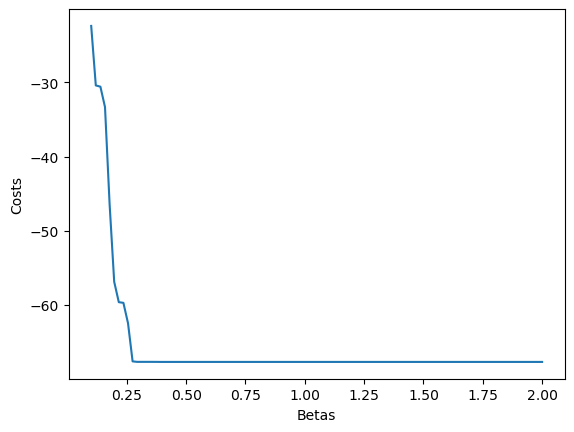

In [213]:
import matplotlib.pyplot as plt

#modified version of the simulated annealing function:
def simann_3(n , ID, table = None, beta0 = 0.1, beta1= 2, anneal_steps = 100 , mcmc_steps=200, seed = None): 
    if seed is not None: 
        np.random.seed(seed)

    if table is None: 
        table = generate_data(n, ID)
    
    probl = Probl(table)
    probl.init_config() 
    cx = probl.cost()
    best_c = cx
    
    betas = np.zeros(anneal_steps)
    betas[:-1] = np.linspace(beta0, beta1, anneal_steps-1) 
    betas[-1] = np.inf 
    
    costs = []
    for beta in betas: 
        accepted_move = 0 
        for t in range(mcmc_steps):
            move = probl.propose_move() 
            delta_c = probl.compute_delta_cost(move)

            if accept_with_prob(delta_c, beta):
                accepted_move += 1
                probl.accept_move(move) 
                cx += delta_c 
                #print(f"beta = {beta},accept_freq = {accepted_move/mcmc_steps} c = {cx}, best_c = {best_c}") 
                    
            if best_c >= cx: 
                best_c = cx 
                best_probl = probl.copy() 
    
        #print(f"best cost = {best_c}")
        costs.append(best_c)
    return betas, costs
    # this new version of simann will return two arrays: one is the array containing all the betas, and the other 
    # contains the best cost for each beta 

#To have statistically significant results, I run the previous function many times and get the average best cost 
def get_mean_results(n, ID, table = None, iterations=20, anneal_steps=100): 
        costs = np.zeros((iterations, anneal_steps))
        # I re-iterate the algorithm iterations times
        for i in range(iterations-1):
            betas, c = simann_3(n, ID, table = None, anneal_steps=anneal_steps)
            costs[i,:] = c
        avg_costs = np.mean(costs, axis=0)
        return betas, avg_costs #this function returns the betas and the average cost that can be obtained for each beta

#Now I need to plot the results I obtained: 
def plot_task3(betas, avg_costs):
   plt.plot(betas, avg_costs, label= "Average cost" )
   plt.xlabel("Betas")
   plt.ylabel("Costs")
# The graph obtained shows how the costs varies as beta changes 

betas, avg_costs = get_mean_results(100, "3197417", table = None, anneal_steps= 100)
plot_task3(betas, avg_costs)


TASK 4 - PERFORMANCE FOR DIFFERENT DIMENSIONS
𝑛 = [100, 200, 500, 1000, 5000] convergence speed and convergence success.

To study these variables, I will provide a simulated annealing code that will return the convergence speed and convergence success. 
To study the convergence speed I used the time measure. To study the convergence success, I will stop algorithm when the acceptance rate is zero, in fact at this stage the possibility of the point to change its position is very low. 
I consider a successfull convergence when the point resulting from the algorithm is in a neighbour of the actual minimum. 

In [209]:
import time 
       
def simann_4(n , ID, table = None, beta0 = 0.1, beta1= 10, anneal_steps = 50 , mcmc_steps=20, seed = None): 
    if seed is not None: 
        np.random.seed(seed)

    if table is None: 
        table = generate_data(n, ID)
    
    probl = Probl(table)
    probl.init_config() 
    cx = probl.cost()
    # print(f"initial cost is c = {cx}")

    t0 = time.time() #this is the initial time 

    actual_minimum = np.min(probl.table)
    #print(f"actual_min = {actual_minimum}")
    
    best_c =cx 
    best_probl= probl.copy()
    betas = np.zeros(anneal_steps)
    betas[:-1] = np.linspace(beta0, beta1, anneal_steps-1) 
    betas[-1] = np.inf 

    for beta in betas: 
        accepted_move = 0 
        for t in range(mcmc_steps):
            move = probl.propose_move() 
            delta_c = probl.compute_delta_cost(move)

            if accept_with_prob(delta_c, beta):
                accepted_move += 1
                probl.accept_move(move) 
                cx += delta_c 

            if best_c >= cx: 
                best_c = cx 
                best_probl = probl.copy()

        accept_freq = accepted_move / mcmc_steps
        
        if accept_freq == 0: 
            convergence_success = (abs(best_c - actual_minimum) < 3)
            t1 = time.time()
            t = t1 - t0
            return best_c, t , convergence_success
           
    convergence_success = (abs(best_c - actual_minimum) < 5)
    t1 = time.time() #final time 
    t = t1- t0 #execution time 
              
    #print(f"best cost = {best_c}")
    return best_c, t, convergence_success

#To have a more general result, I run this new version of simann 20 times for each n and take the everage resut, to do 
#so I implement the function mean_results

def mean_results(n, ID= "3197417", table = None, iterations = 20): 
    time = np.zeros(iterations, dtype=float)
    success = np.zeros(iterations, dtype=int)
    for i in range(iterations): 
        best_c, t, convergence_success = simann_4(n, ID, table = None)
        time[i] = t
        success[i] = convergence_success
    t = np.mean(time)
    s = np.mean(success)
    return t, s 

#Now I need to get the average result for each value of n 

def info_performance(n): 
    l = len(n)
    times = np.zeros(l)
    success_rate = np.zeros(l)
    for i in range(l): 
        t, s = mean_results(n[i], ID = "3197417", table = None, iterations = 20)
        times[i] = t
        success_rate[i] = s 
    return times, success_rate 

n = [100, 200, 500, 1000, 5000]
info_performance(n)

(array([0.02865045, 0.04901279, 0.06292336, 0.10527562, 1.20595312]),
 array([0.15, 0.15, 0.05, 0.  , 0.  ]))

Running the function info_performance for n = [100, 200, 500, 1000, 5000] we get: 
- times = [0.03973931, 0.03793021, 0.04709876, 0.07141582, 1.76944939]
- success_rate = [0.55, 0.25, 0.05, 0.  , 0.  ]
these are two arrays, and each element of times and success_rate corresponds respectively to the average time needed by the algorithm to converge and the success rate for each value of n(i.e. dimension of the matrix). 


TASK 5 - ACCEPTANCE PROBABILITIES 

To study the behavior of acceptance probability it is possible to use the measure of the accepted frequency.
Another element that we need to take into account is beta, in fact we expect a reduction in the acceptance rate of proposals as beta increases. 


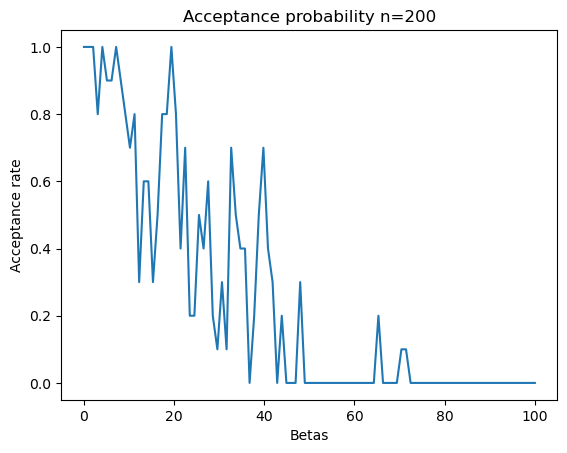

In [217]:
def simann_5(n , ID, table = None, beta0 = 0.01, beta1= 100, anneal_steps = 100, mcmc_steps=10, seed = None): 
    if seed is not None: 
        np.random.seed(seed)

    if table is None: 
        table = generate_data(n, ID)
    
    probl = Probl(table)
    
    probl.init_config() 
    cx = probl.cost()
    # print(f"initial cost is c = {cx}")
    
    best_c =cx 
    best_probl= probl.copy()

    betas = np.zeros(anneal_steps)
    betas[:-1] = np.linspace(beta0, beta1, anneal_steps-1) 
    betas[-1] = np.inf 
    
    #array that will contain the accepted frequency for each beta
    accepted_freq = np.zeros(anneal_steps) 
    

    for i in range(anneal_steps): 
        beta = betas[i]
        accepted_move = 0 
        for t in range(mcmc_steps):
            #array that will contain the reduction in cost every time a move is accepted
            # (if the move is not accepted, I set delta cost to zero)
            move = probl.propose_move() 
            delta_c = probl.compute_delta_cost(move)

            if accept_with_prob(delta_c, beta):
                accepted_move += 1
                probl.accept_move(move) 
                cx += delta_c 
            #print(f"beta = {beta},accept_freq = {accepted_move/mcmc_steps} c = {cx}, best_c = {best_c}")

            if best_c >= cx: 
                best_c = cx 
                best_probl = probl.copy() 

        accepted_freq[i] = accepted_move/mcmc_steps  #CONTROLLA 
        
    
    #print(f"best cost = {best_c}")
    return accepted_freq, betas 

def plot_task5(accepted_freq, betas):
   plt.plot(betas, accepted_freq, label = "Acceptance Frequency" )
   plt.xlabel("Betas")
   plt.ylabel("Acceptance rate")
   plt.title("Acceptance probability n=200")

accepted_freq, betas = simann_5(200, "3197417", table= None,anneal_steps = 100, mcmc_steps=10, seed = None )
plot_task5(accepted_freq, betas)


        

TASK 6 - OPTIMIZATION FOR A FIXED N 

To have a good visualization of the landscape we are optimizing it is sufficiently to run the function "visualize" that I implemented after the "generate_data" function. Then I will plot the best coordinates obtained from the simulated annealing procedure

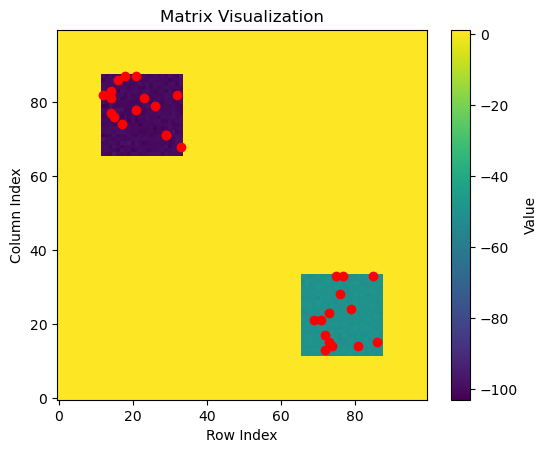

In [218]:

#to visualize the optimization process 
# I create a new version of the simann function to get the best coordinates
def accept_with_prob(delta_cost, beta):
    if delta_cost <= 0: #cost is decreasing, move is accepted 
         return True
     
    if beta == np.inf: 
        return False 
    
    prob = np.exp(- beta* delta_cost) #acceptance probability is between 0 and 1
    return np.random.random() < prob
    

def simann_6(n , ID, table = None, beta0 = 0.1, beta1= 1, anneal_steps = 100 , mcmc_steps=200, seed = None): 
    if seed is not None: 
        np.random.seed(seed)

    if table is None: 
        table = generate_data(n, ID)
    
    probl = Probl(table)
    
    probl.init_config() 
    cx = probl.cost()
    # print(f"initial cost is c = {cx}")
    
    best_c =cx 
    best_probl= probl.copy()

    betas = np.zeros(anneal_steps)
    betas[:-1] = np.linspace(beta0, beta1, anneal_steps-1) 
    betas[-1] = np.inf 
    
    for beta in betas: 
       accepted_move = 0 
       for t in range(mcmc_steps):

            move = probl.propose_move() 
            delta_c = probl.compute_delta_cost(move)

            if accept_with_prob(delta_c, beta):
                accepted_move += 1
                probl.accept_move(move) 
                cx += delta_c 
                coord = probl.i, probl.j
            #print(f"beta = {beta},accept_freq = {accepted_move/mcmc_steps} c = {cx}, best_c = {best_c}")
        
            
            if best_c >= cx: 
                best_c = cx 
                best_probl = probl.copy() 
                best_coord = best_probl.i, best_probl.j
    
    #print(f"best cost = {best_c}")
    return best_coord, best_c

#I plot the optimal coordinates the algorithm founds onto the graph of the visualization of the function
def show_opt(n, ID, times = 20 ): 
    for i in range(times): 
        p, c = (simann_6(n , ID, table = None, beta0 = 0.1, beta1= 2, anneal_steps = 100 , mcmc_steps=200, seed = None))
        x0, y0 = p 
        plt.plot(x0, y0, marker="o", color="red")

show_opt(100, "3197417", times = 30)
visualize(100, "3197417")


TASK 7 - In the answers file 